# Step 1. 단변량 분포 확인 (Univariate EDA) - 필수/애매/불필요 비교판

경기도 카드소비 x 날씨 데이터 EDA 1단계.
목표: 매출 관련 변수와 날씨 변수 각각의 분포를 확인하고, 이상치/왜도/로그변환 필요 여부를 판단한다.
이번 버전은 소분류를 '필수(24개)/애매(17개)/불필요(42개)' 3개 그룹으로 나눠 비교하며 진행한다.

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
%matplotlib inline

## 1-0. 데이터 로드

split_by_category.py로 미리 나눠둔 필수/애매/불필요 3개 parquet을 각각 불러오고,
'분류등급' 컬럼을 붙여 하나로 합친다 (그룹별 비교를 위해).

In [ ]:
from pathlib import Path

# src/analysis/ 에서 실행하는 걸 기준으로 프로젝트 루트까지 2단계 상위 경로.
CATEGORY_DIR = Path("../../data/processed/consume_weather_by_category")

GROUP_ORDER = ["필수", "애매", "불필요"]

# 각 분류별 데이터프레임을 임시로 저장해 둘 딕셔너리를 생성
group_dfs = {}

# "필수" -> "애매" -> "불필요" 순서대로 순회하며 파일 읽기 작업을 수행
for group in GROUP_ORDER:
    g_df = pd.read_parquet(CATEGORY_DIR / f"{group}.parquet")
    
    # 여러 데이터를 하나로 합친 후에도 출처를 구분할 수 있도록 '분류등급' 컬럼을 새로 만들고 그룹명을 입력
    g_df["분류등급"] = group
    
    group_dfs[group] = g_df
    
    #정상적으로 로드되었는지 중간 확인
    print(f"{group}: {len(g_df):,}행, 소분류 {g_df['소분류'].nunique()}개")

# 딕셔너리에 담긴 3개 그룹("필수", "애매", "불필요")의 데이터프레임들을 위아래로 수직 통합
df = pd.concat(group_dfs.values(), ignore_index=True)
print()
print("전체 shape:", df.shape)
df.head()

필수: 1,192,654행, 소분류 24개
애매: 699,292행, 소분류 17개
불필요: 1,532,905행, 소분류 42개

전체 shape: (3424851, 15)


,날짜,대분류,소분류,연령 그룹,매출금액,매출건수,건당 매출금액,도시,지점명,date,평균기온(°C),일강수량(mm),평균 풍속(m/s),일 최심적설(cm),분류등급
0,20220101,생활서비스,연료판매,1,166896,6,27816.00,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0,필수
1,20220101,생활서비스,연료판매,2,167224232,3941,42431.93,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0,필수
2,20220101,생활서비스,연료판매,3,496889979,8970,55394.65,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0,필수
3,20220101,생활서비스,연료판매,4,24285970,389,62431.80,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0,필수
4,20220101,소매/유통,건강/기호식품,1,8805,2,4402.50,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0,필수


## 1-0-1. 기본 정보 확인

In [3]:
print(df.dtypes)
print()
print("기간:", df["date"].min(), "~", df["date"].max())
print("도시:", sorted(df["도시"].unique()))
print("권역:", sorted(df["지점명"].unique()))
print("연령그룹:", sorted(df["연령 그룹"].unique()))
print("분류등급별 행 수:")
print(df["분류등급"].value_counts().reindex(GROUP_ORDER))
print()
print("결측치:")
print(df.isna().sum())

날짜                     int64
대분류                      str
소분류                      str
연령 그룹                  int64
매출금액                   int64
매출건수                   int64
건당 매출금액              float64
도시                       str
지점명                      str
date          datetime64[us]
평균기온(°C)             float64
일강수량(mm)             float64
평균 풍속(m/s)           float64
일 최심적설(cm)           float64
분류등급                     str
dtype: object

기간: 2022-01-01 00:00:00 ~ 2025-12-31 00:00:00
도시: ['광명시', '수원시', '시흥시', '안산시', '안양시', '용인시', '포천시', '하남시', '화성시']
권역: ['남부', '동부', '북부']
연령그룹: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
분류등급별 행 수:
분류등급
필수     1192654
애매      699292
불필요    1532905
Name: count, dtype: int64

결측치:
날짜             0
대분류            0
소분류            0
연령 그룹          0
매출금액           0
매출건수           0
건당 매출금액       11
도시             0
지점명            0
date           0
평균기온(°C)       0
일강수량(mm)       0
평균 풍속(m/s)     0
일 최심적설(cm)     0
분류등급           0
dtype:

## 1-1. 매출금액 분포 (분류등급별 비교)

카드 소비 데이터는 소수 초고액 결제 때문에 오른쪽 꼬리가 긴 분포가 흔하다.
분류등급별로 왜도와 로그변환 분포를 같이 비교해서, '불필요' 그룹이 실제로
극단값을 더 많이 포함하는지, '필수' 그룹이 상대적으로 정돈된 분포인지 확인한다.

In [4]:
print(df.groupby("분류등급")["매출금액"].describe().reindex(GROUP_ORDER))
print()
print("분류등급별 왜도(skewness):")
print(df.groupby("분류등급")["매출금액"].skew().reindex(GROUP_ORDER))

          count          mean           std   min         25%         50%  \
분류등급                                                                        
필수    1192654.0  1.134524e+08  3.496162e+08  17.0  1411461.75  16744121.5   
애매     699292.0  4.508513e+07  1.786373e+08   0.0   387054.25   2706285.0   
불필요   1532905.0  3.748017e+07  1.857783e+08   0.0   310379.00   2836830.0   

              75%           max  
분류등급                             
필수    79871117.75  9.270647e+09  
애매    19349458.75  7.626981e+09  
불필요   19018380.00  1.194895e+10  

분류등급별 왜도(skewness):
분류등급
필수      7.541444
애매     10.722723
불필요    22.420316
Name: 매출금액, dtype: float64


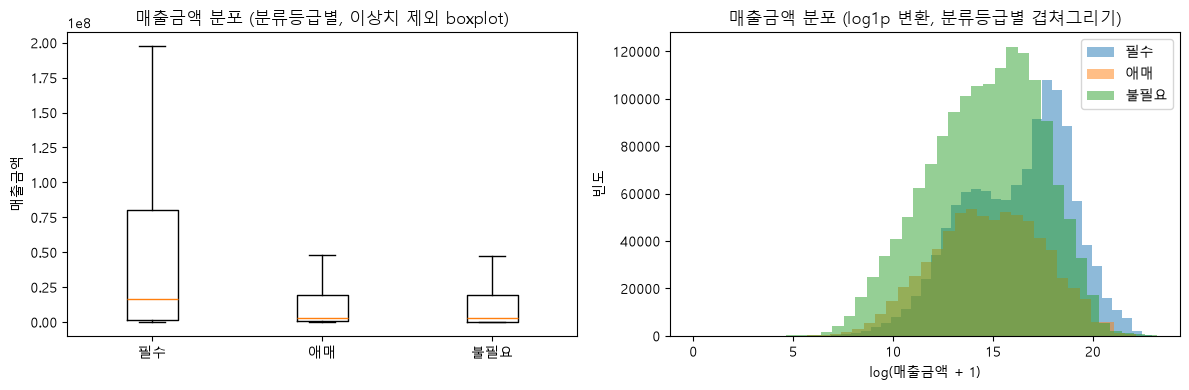

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 분류등급별 매출금액 박스 플롯
box_data = [df.loc[df["분류등급"] == g, "매출금액"] for g in GROUP_ORDER]
axes[0].boxplot(box_data, tick_labels=GROUP_ORDER, showfliers=False)
axes[0].set_title("매출금액 분포 (분류등급별, 이상치 제외 boxplot)")
axes[0].set_ylabel("매출금액")

# 로그 변환된 매출금액 히스토그램
# "필수", "애매", "불필요" 각 등급을 순회환 후, 등급별 데이터를 하나의 히스토그램에 겹쳐서 그리기
for g in GROUP_ORDER:
    axes[1].hist(np.log1p(df.loc[df["분류등급"] == g, "매출금액"]), bins=40, alpha=0.5, label=g)
axes[1].set_title("매출금액 분포 (log1p 변환, 분류등급별 겹쳐그리기)")
axes[1].set_xlabel("log(매출금액 + 1)")
axes[1].set_ylabel("빈도")
axes[1].legend()

plt.tight_layout()
plt.show()

## 1-2. 매출건수 분포 (분류등급별 비교)

In [6]:
print(df.groupby("분류등급")["매출건수"].describe().reindex(GROUP_ORDER))
print()
print("분류등급별 왜도(skewness):")
print(df.groupby("분류등급")["매출건수"].skew().reindex(GROUP_ORDER))

          count         mean           std  min   25%    50%     75%       max
분류등급                                                                          
필수    1192654.0  4533.701728  15171.791572  1.0  79.0  589.0  2988.0  271211.0
애매     699292.0   945.579169   2894.713242  1.0  16.0   91.0   568.0   83535.0
불필요   1532905.0   466.412756   1477.764961  0.0  10.0   50.0   288.0   48683.0

분류등급별 왜도(skewness):
분류등급
필수     7.713347
애매     7.828384
불필요    7.833828
Name: 매출건수, dtype: float64


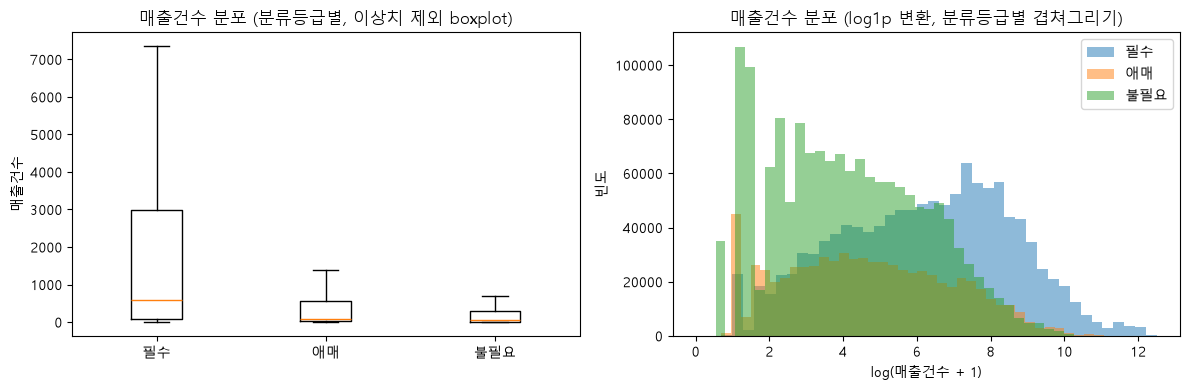

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 분류등급별 매출건수 박스 플롯
box_data = [df.loc[df["분류등급"] == g, "매출건수"] for g in GROUP_ORDER]
axes[0].boxplot(box_data, tick_labels=GROUP_ORDER, showfliers=False)
axes[0].set_title("매출건수 분포 (분류등급별, 이상치 제외 boxplot)")
axes[0].set_ylabel("매출건수")

# 로그 변환된 매출건수 히스토그램
for g in GROUP_ORDER:
    axes[1].hist(np.log1p(df.loc[df["분류등급"] == g, "매출건수"]), bins=40, alpha=0.5, label=g)
axes[1].set_title("매출건수 분포 (log1p 변환, 분류등급별 겹쳐그리기)")
axes[1].set_xlabel("log(매출건수 + 1)")
axes[1].set_ylabel("빈도")
axes[1].legend()

plt.tight_layout()
plt.show()

## 1-3. 건당 매출금액(단가) 분포 (분류등급별 비교)

In [8]:
print(df.groupby("분류등급")["건당 매출금액"].describe().reindex(GROUP_ORDER))
print()
print("분류등급별 왜도(skewness):")
print(df.groupby("분류등급")["건당 매출금액"].skew().reindex(GROUP_ORDER))

          count           mean            std  min         25%        50%  \
분류등급                                                                        
필수    1192654.0   30777.356412   32224.736915  8.5  12466.3300  24070.875   
애매     699292.0   51011.673094  113275.514913  0.0  13730.9775  24683.300   
불필요   1532894.0  138919.814716  454986.985680  0.0  13834.0275  45986.500   

             75%         max  
분류등급                          
필수     41205.380   4306632.0  
애매     49949.955  16801075.5  
불필요   133009.275  94189394.0  

분류등급별 왜도(skewness):
분류등급
필수     18.502680
애매     26.711133
불필요    32.510313
Name: 건당 매출금액, dtype: float64


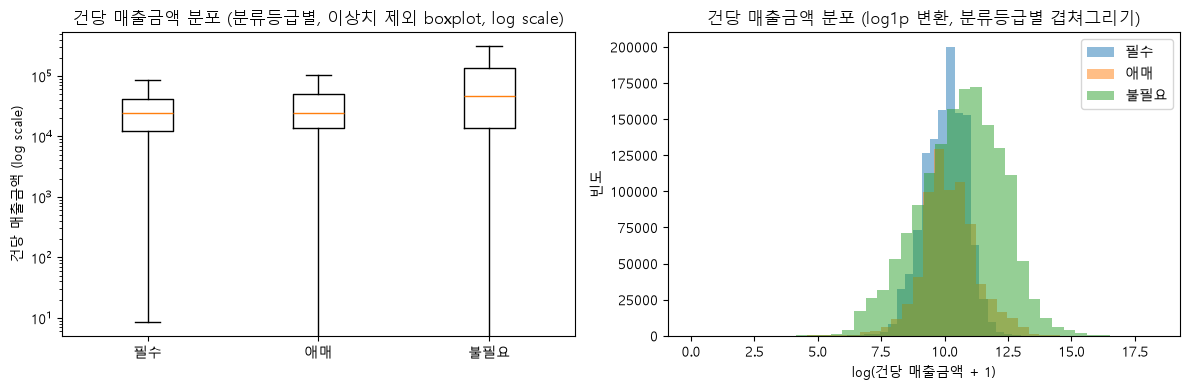

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 분류등급별 건당 매출금액 박스 플롯
box_data = [df.loc[df["분류등급"] == g, "건당 매출금액"].dropna() for g in GROUP_ORDER]
axes[0].boxplot(box_data, tick_labels=GROUP_ORDER, showfliers=False)
axes[0].set_yscale("log")
axes[0].set_title("건당 매출금액 분포 (분류등급별, 이상치 제외 boxplot, log scale)")
axes[0].set_ylabel("건당 매출금액 (log scale)")

# 로그 변환된 건당 매출금액 히스토그램
for g in GROUP_ORDER:
    axes[1].hist(np.log1p(df.loc[df["분류등급"] == g, "건당 매출금액"].dropna()), bins=40, alpha=0.5, label=g)
axes[1].set_title("건당 매출금액 분포 (log1p 변환, 분류등급별 겹쳐그리기)")
axes[1].set_xlabel("log(건당 매출금액 + 1)")
axes[1].set_ylabel("빈도")
axes[1].legend()

plt.tight_layout()
plt.show()

## 1-4. 이상치 스캔 (분류등급별)

음수이거나 비정상적으로 극단적인 값이 있는지, 그리고 그 정도가 분류등급별로
얼마나 다른지 확인한다.

In [ ]:
for col in ["매출금액", "매출건수", "건당 매출금액"]:
    print(f"=== {col} ===")
    for g in GROUP_ORDER:
        sub = df.loc[df["분류등급"] == g, col]
        # [데이터 무결성 검증]
        n_negative = (sub < 0).sum()
        # [상위 극단값 파악]
        q99 = sub.quantile(0.99)
        # [최상위 극단값 파악]
        q999 = sub.quantile(0.999)
        print(f"  [{g}] 음수: {n_negative}건, 99%: {q99:,.0f}, 99.9%: {q999:,.0f}, 최대값: {sub.max():,.0f}")
    print()

=== 매출금액 ===
  [필수] 음수: 0건, 99%: 1,752,549,026, 99.9%: 3,973,088,523, 최대값: 9,270,646,767
  [애매] 음수: 0건, 99%: 870,726,585, 99.9%: 2,589,174,658, 최대값: 7,626,981,188
  [불필요] 음수: 0건, 99%: 514,975,122, 99.9%: 2,564,741,595, 최대값: 11,948,948,791

=== 매출건수 ===
  [필수] 음수: 0건, 99%: 85,460, 99.9%: 182,509, 최대값: 271,211
  [애매] 음수: 0건, 99%: 14,785, 99.9%: 39,236, 최대값: 83,535
  [불필요] 음수: 0건, 99%: 7,003, 99.9%: 18,640, 최대값: 48,683

=== 건당 매출금액 ===
  [필수] 음수: 0건, 99%: 126,231, 99.9%: 281,014, 최대값: 4,306,632
  [애매] 음수: 0건, 99%: 424,935, 99.9%: 1,132,789, 최대값: 16,801,076
  [불필요] 음수: 0건, 99%: 1,363,884, 99.9%: 5,718,692, 최대값: 94,189,394



In [16]:
# 전체 데이터 기준 상위 20건이 어느 분류등급/소분류에서 나오는지 확인
top20 = df.nlargest(20, "건당 매출금액")[
    ["날짜", "도시", "분류등급", "대분류", "소분류", "연령 그룹", "매출금액", "매출건수", "건당 매출금액"]
]
top20

,날짜,도시,분류등급,대분류,소분류,연령 그룹,매출금액,매출건수,건당 매출금액
2188190,20220124,광명시,불필요,소매/유통,차량판매,4,376757576,4,94189394.00
1907417,20220612,포천시,불필요,생활서비스,가례서비스,4,166103338,2,83051669.00
3134775,20231006,용인시,불필요,생활서비스,부동산,3,144270439,2,72135219.50
3292019,20230130,화성시,불필요,생활서비스,여행/유학대행,3,140221969,2,70110984.50
2187890,20220121,광명시,불필요,소매/유통,차량판매,4,113937879,2,56968939.50
3245766,20220111,화성시,불필요,소매/유통,차량판매,4,308673068,8,38584133.50
2238665,20230602,광명시,불필요,소매/유통,차량판매,2,589236818,16,36827301.12
3072351,20220619,용인시,불필요,소매/유통,차량판매,3,300945271,10,30094527.10
3186214,20241025,용인시,불필요,생활서비스,가례서비스,4,875358309,30,29178610.30
2443939,20240310,수원시,불필요,소매/유통,차량판매,2,57571765,2,28785882.50


## 1-5. 날씨 변수 분포

날씨는 분류등급과 무관하게 동일하므로(같은 날짜엔 같은 날씨), 전체 데이터 기준 1회만 확인한다.

          평균기온(°C)     일강수량(mm)   평균 풍속(m/s)   일 최심적설(cm)
count  4383.000000  4383.000000  4383.000000  4383.000000
mean     12.995587     3.992788     1.420308     0.047661
std      10.641041    13.165432     0.709639     0.385245
min     -12.800000     0.000000     0.200000     0.000000
25%       3.600000     0.000000     0.900000     0.000000
50%      14.300000     0.000000     1.300000     0.000000
75%      22.400000     0.400000     1.800000     0.000000
max      30.661800   106.654000     4.761800     4.018000


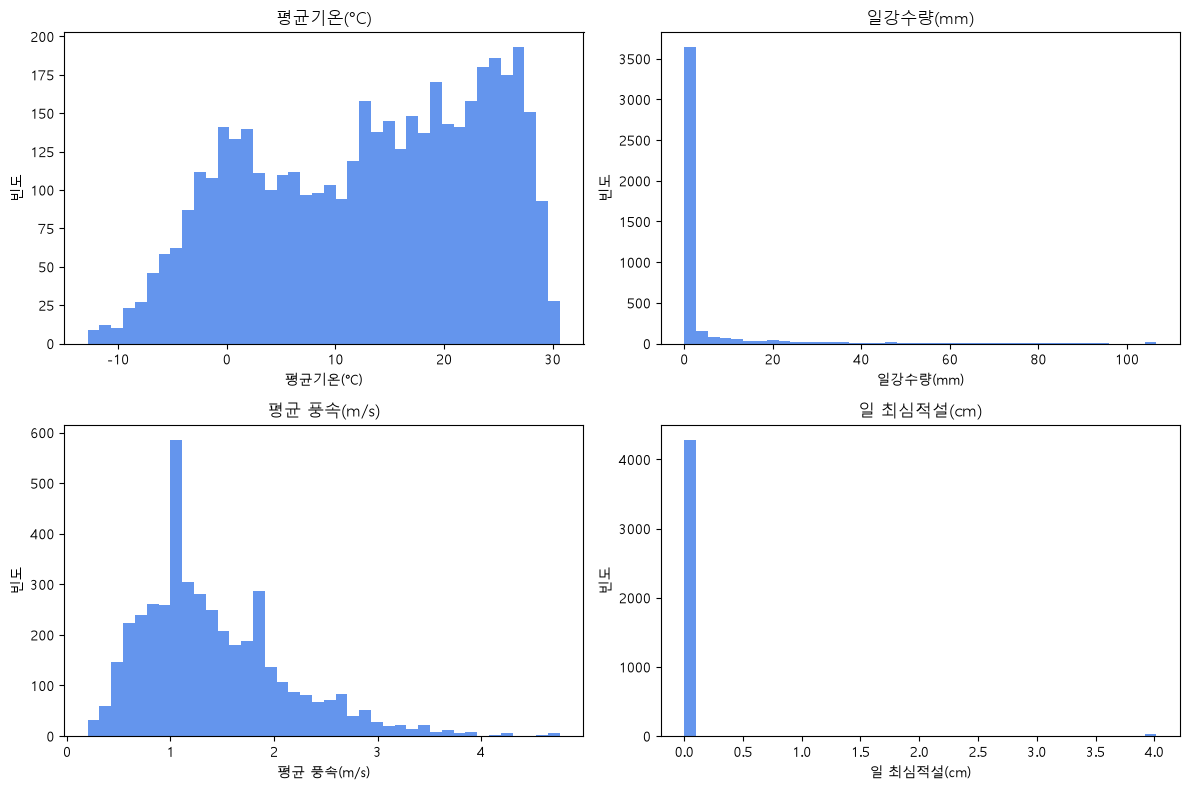

In [ ]:
# 분석하고자 하는 핵심 기상 변수 4개의 이름을 리스트로 지정
weather_cols = ["평균기온(°C)", "일강수량(mm)", "평균 풍속(m/s)", "일 최심적설(cm)"]

# 날짜+지점명 기준 중복 제거 (같은 날씨값이 여러 소분류 행에 반복되므로)
weather_unique = df.drop_duplicates(subset=["date", "지점명"])[weather_cols]

print(weather_unique.describe())

# 각 날씨 컬럼 데이터의 빈도 분포를 히스토그램으로 그리기
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, weather_cols):
    ax.hist(weather_unique[col], bins=40, color="cornflowerblue")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("빈도")

plt.tight_layout()
plt.show()